Below is a model designed to compare the performance of reinforcement learning-based adaptive control model with traditional PID control approaches regarding accuracy, response time, and energy consumption. The exploration strategy used in this reinforcement learning model is epsilon-greedy

Comparison between RL and PID controllers:
Accuracy (lower is better):
RL - Average Accuracy: 0.25
PID - Average Accuracy: 0.32

Response Time (lower is better):
RL - Average Response Time: 4.32
PID - Average Response Time: 50.00

Energy Consumption (lower is better):
RL - Average Energy Consumption: 15.42
PID - Average Energy Consumption: 7889.75



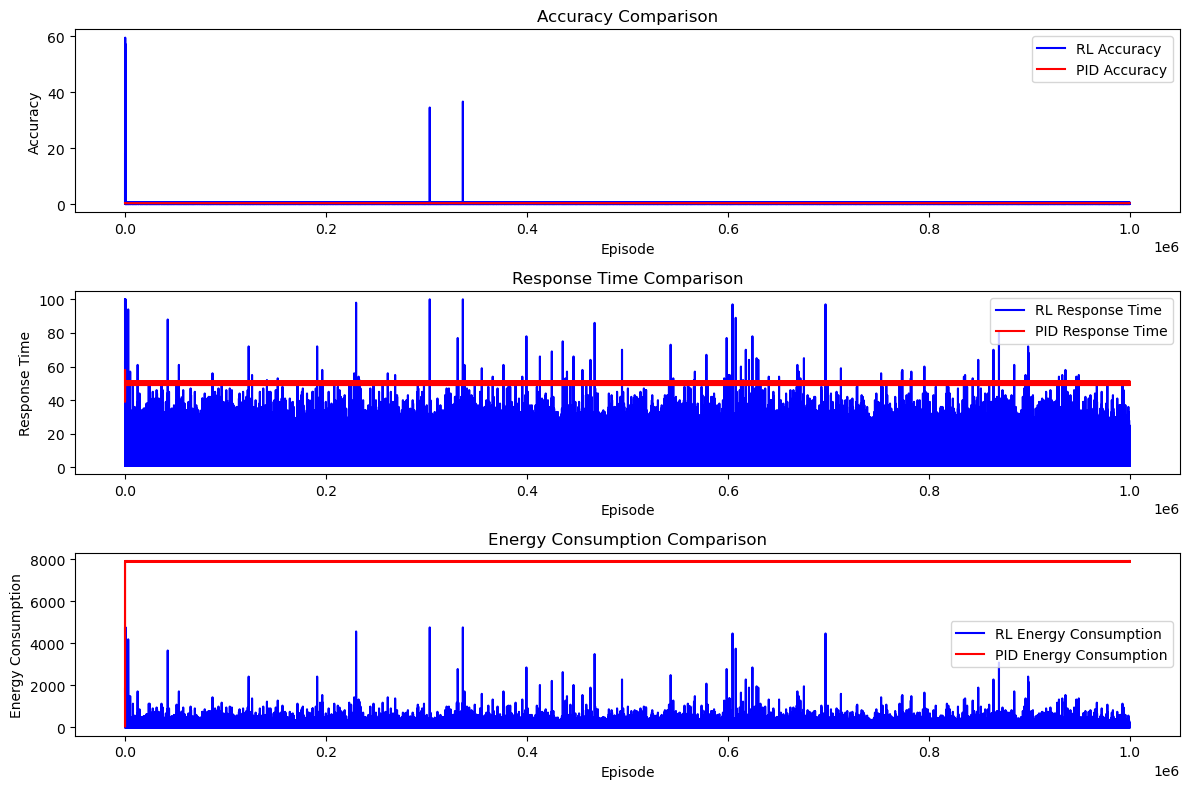

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# Defining the Q-Learning based controller
class QLearning:
    def __init__(self, state_space_dims, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64):
        self.state_space_dims = state_space_dims
        self.action_space_size = action_space_size
        self.q_table = np.zeros((*state_space_dims, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay  
        self.min_epsilon = min_epsilon
        self.memory = deque(maxlen=replay_size)
        self.batch_size = batch_size

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(range(self.action_space_size))  # Exploration
        else:
            return np.argmax(self.q_table[state])  # Exploitation

    def update_q_table(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        if len(self.memory) >= self.batch_size:
            self.replay_experience()

    def replay_experience(self):
        batch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state in batch:
            best_next_action = np.argmax(self.q_table[next_state])
            td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
            td_error = td_target - self.q_table[state][action]
            self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

# Defining the Traditional PID controller
class PIDController:
    def __init__(self, Kp, Ki, Kd, setpoint=22):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.setpoint = setpoint
        self.integral = 0
        self.previous_error = 0

    def compute(self, current_temp):
        error = self.setpoint - current_temp
        self.integral += error
        derivative = error - self.previous_error
        output = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        self.previous_error = error
        return output

# Defining the Environment
class HVACEnvironment:
    def __init__(self, room_size, insulation, external_temp, hvac_power, random_initial_temp=True):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.time_of_day = 0
        self.occupancy_status = 1
        self.temp_bins = np.linspace(15, 30, 10)
        self.time_bins = np.linspace(0, 23, 24)
        
        if random_initial_temp:
            self.current_temp = np.random.uniform(10, 35)
        else:
            self.current_temp = self.external_temp

    def discretize_state(self):
        temp_state = np.digitize(self.current_temp, self.temp_bins) - 1
        time_state = np.digitize(self.time_of_day, self.time_bins) - 1
        return (temp_state, time_state, self.occupancy_status)

    def step(self, action):
        action = max(0, min(action, 4))  # Ensure+ring the action is within range
        temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        self.current_temp += temp_change
        
        target_temp = 22 if self.occupancy_status == 1 else 18
        deviation = abs(self.current_temp - target_temp)
        if deviation < 0.5:
            reward = 10
        elif deviation < 1.0:
            reward = 5
        else:
            reward = -10  # The penalty is capped to prevent extreme negative rewards

        self.time_of_day = (self.time_of_day + 1) % 24
        self.occupancy_status = random.choice([0, 1])

        discrete_state = self.discretize_state()
        return discrete_state, reward

    def find_ku_and_tu(self, pid_controller, max_steps=1000):
        Ku = 0
        Tu = 0
        step = 1
        previous_temp = self.current_temp
        oscillations = []
        for i in range(max_steps):
            pid_controller.Kp += step
            previous_temp = self.current_temp
            for _ in range(100):  # This code allows it to run for a number of steps to observe osciallation
                action = pid_controller.compute(self.current_temp)
                _, _ = self.step(action)  # Updating the environment using available information
                if i > 10:  # Measurement starts after some initial steps
                    oscillation = abs(self.current_temp - previous_temp)
                    if oscillation > 0.1:  
                        oscillations.append(oscillation)
            if len(oscillations) > 0:
                Ku = pid_controller.Kp
                Tu = np.mean(oscillations)  # Claculation for the average oscillation period
                break
            if i % 10 == 0:
                step += 1
        return Ku, Tu

# FOr the Simulation process
num_episodes = 1000000

# Defining the environment and agent for Reinforcement learning
state_space_dims = (10, 24, 2)  
action_space_size = 5
rl_agent = QLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64)

# Initializing environment
env_rl = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)
env_pid = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)

# Ziegler-Nichols Tuning
pid_controller = PIDController(Kp=0, Ki=0, Kd=0)
Ku, Tu = env_pid.find_ku_and_tu(pid_controller)
Kp = 0.6 * Ku
Ki = 2 * Kp / Tu
Kd = Kp * Tu / 8
pid_controller = PIDController(Kp=Kp, Ki=Ki, Kd=Kd)

# For storing results
rl_results = {'accuracy': [], 'response_time': [], 'energy_consumption': []}
pid_results = {'accuracy': [], 'response_time': [], 'energy_consumption': []}

# Simulation loop for the Reinforcement Learning agent
for episode in range(num_episodes):
    state = env_rl.discretize_state()
    total_reward = 0
    length = 0
    done = False
    while not done and length < 100:
        action = rl_agent.choose_action(state)
        next_state, reward = env_rl.step(action)
        rl_agent.update_q_table(state, action, reward, next_state)
        state = next_state
        total_reward += reward
        length += 1
        if abs(env_rl.current_temp - (22 if env_rl.occupancy_status == 1 else 18)) < 0.5:
            done = True
    rl_agent.decay_epsilon()
    rl_results['accuracy'].append(abs(env_rl.current_temp - (22 if env_rl.occupancy_status == 1 else 18)))
    rl_results['response_time'].append(length)
    rl_results['energy_consumption'].append(sum([abs(a - 2) for a in range(length)]))

# Simulation loop for the PID controller
for episode in range(num_episodes):
    total_reward = 0
    length = 0
    done = False
    while not done and length < 100:
        action = pid_controller.compute(env_pid.current_temp)
        next_state, reward = env_pid.step(action)
        total_reward += reward
        length += 1
        if abs(env_pid.current_temp - pid_controller.setpoint) < 0.5:
            done = True
    pid_results['accuracy'].append(abs(env_pid.current_temp - pid_controller.setpoint))
    pid_results['response_time'].append(length)
    pid_results['energy_consumption'].append(sum([abs(action - 2) for _ in range(length)]))

# Printing out comparison results
def print_comparison_results(rl_results, pid_results):
    print("Comparison between RL and PID controllers:")
    print("Accuracy (lower is better):")
    print(f"RL - Average Accuracy: {np.mean(rl_results['accuracy']):.2f}")
    print(f"PID - Average Accuracy: {np.mean(pid_results['accuracy']):.2f}\n")
    
    print("Response Time (lower is better):")
    print(f"RL - Average Response Time: {np.mean(rl_results['response_time']):.2f}")
    print(f"PID - Average Response Time: {np.mean(pid_results['response_time']):.2f}\n")
    
    print("Energy Consumption (lower is better):")
    print(f"RL - Average Energy Consumption: {np.mean(rl_results['energy_consumption']):.2f}")
    print(f"PID - Average Energy Consumption: {np.mean(pid_results['energy_consumption']):.2f}\n")

print_comparison_results(rl_results, pid_results)

# Visualization
plt.figure(figsize=(12, 8))

# Plotting accuracy comparison
plt.subplot(3, 1, 1)
plt.plot(rl_results['accuracy'], label='RL Accuracy', color='blue')
plt.plot(pid_results['accuracy'], label='PID Accuracy', color='red')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()

# Plotting response time comparison
plt.subplot(3, 1, 2)
plt.plot(rl_results['response_time'], label='RL Response Time', color='blue')
plt.plot(pid_results['response_time'], label='PID Response Time', color='red')
plt.xlabel('Episode')
plt.ylabel('Response Time')
plt.title('Response Time Comparison')
plt.legend()

# Plotting energy consumption comparison
plt.subplot(3, 1, 3)
plt.plot(rl_results['energy_consumption'], label='RL Energy Consumption', color='blue')
plt.plot(pid_results['energy_consumption'], label='PID Energy Consumption', color='red')
plt.xlabel('Episode')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption Comparison')
plt.legend()

plt.tight_layout()
plt.show()


Below is a model designed to compare the performance of reinforcement learning-based adaptive control model with traditional PID control approaches regarding accuracy, response time, and energy consumption. The exploration strategy used in this reinforcement learning model is SoftMax

Comparison between RL and PID controllers:
Accuracy (lower is better):
RL - Average Accuracy: 0.24
PID - Average Accuracy: 0.32

Response Time (lower is better):
RL - Average Response Time: 4.13
PID - Average Response Time: 50.00

Energy Consumption (lower is better):
RL - Average Energy Consumption: 12.75
PID - Average Energy Consumption: 7889.75



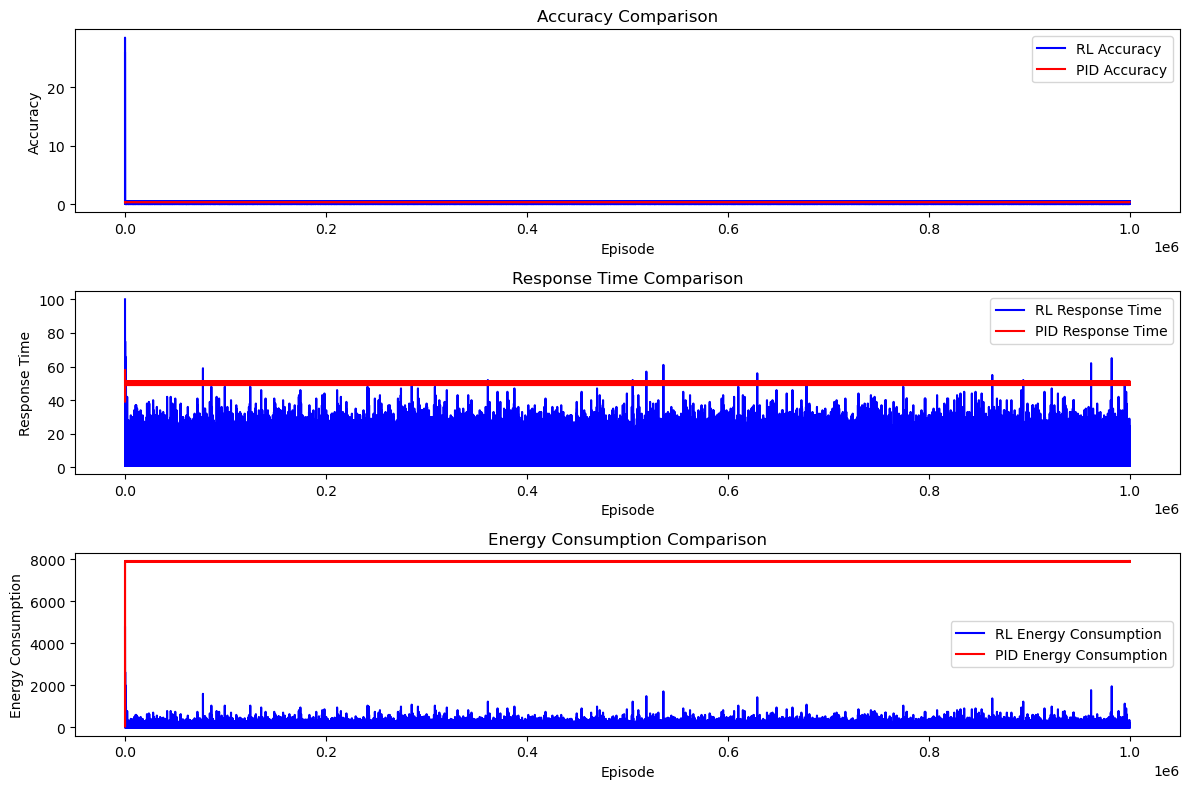

In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# This is the SoftMax function used for action selection
def softmax(q_values, temperature=1.0):
    exp_q = np.exp(q_values / temperature)  
    return exp_q / np.sum(exp_q)

# Q-Learning based controller with integrated with Softmax action selection
class QLearning:
    def __init__(self, state_space_dims, action_space_size, alpha=0.1, gamma=0.9, replay_size=10000, batch_size=64, temperature=1.0):
        self.state_space_dims = state_space_dims
        self.action_space_size = action_space_size
        self.q_table = np.zeros((*state_space_dims, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.memory = deque(maxlen=replay_size)
        self.batch_size = batch_size
        self.temperature = temperature  

    def choose_action(self, state):
        q_values = self.q_table[state]
        action_probabilities = softmax(q_values, self.temperature)
        return np.random.choice(range(self.action_space_size), p=action_probabilities)  # SoftMax chooses actions based on probabilities

    def update_q_table(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        if len(self.memory) >= self.batch_size:
            self.replay_experience()

    def replay_experience(self):
        batch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state in batch:
            best_next_action = np.argmax(self.q_table[next_state])
            td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
            td_error = td_target - self.q_table[state][action]
            self.q_table[state][action] += self.alpha * td_error

# Traditional PID controller
class PIDController:
    def __init__(self, Kp, Ki, Kd, setpoint=22):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.setpoint = setpoint
        self.integral = 0
        self.previous_error = 0

    def compute(self, current_temp):
        error = self.setpoint - current_temp
        self.integral += error
        derivative = error - self.previous_error
        output = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        self.previous_error = error
        return output

# Creating the Environment model
class HVACEnvironment:
    def __init__(self, room_size, insulation, external_temp, hvac_power, random_initial_temp=True):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.time_of_day = 0
        self.occupancy_status = 1
        self.temp_bins = np.linspace(15, 30, 10)
        self.time_bins = np.linspace(0, 23, 24)
        
        if random_initial_temp:
            self.current_temp = np.random.uniform(10, 35)
        else:
            self.current_temp = self.external_temp

    def discretize_state(self):
        temp_state = np.digitize(self.current_temp, self.temp_bins) - 1
        time_state = np.digitize(self.time_of_day, self.time_bins) - 1
        return (temp_state, time_state, self.occupancy_status)

    def step(self, action):
        action = max(0, min(action, 4))  # Ensuring the action is within range
        temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        self.current_temp += temp_change
        
        target_temp = 22 if self.occupancy_status == 1 else 18
        deviation = abs(self.current_temp - target_temp)
        if deviation < 0.5:
            reward = 10
        elif deviation < 1.0:
            reward = 5
        else:
            reward = -10  # This line helps to avoid extremely negative rewards

        self.time_of_day = (self.time_of_day + 1) % 24
        self.occupancy_status = random.choice([0, 1])

        discrete_state = self.discretize_state()
        return discrete_state, reward

    def find_ku_and_tu(self, pid_controller, max_steps=1000):
        Ku = 0
        Tu = 0
        step = 1
        previous_temp = self.current_temp
        oscillations = []
        for i in range(max_steps):
            pid_controller.Kp += step
            previous_temp = self.current_temp
            for _ in range(100):  # This code is run for a number of steps to observe oscillation
                action = pid_controller.compute(self.current_temp)
                _, _ = self.step(action)  
                if i > 10:  
                    oscillation = abs(self.current_temp - previous_temp)
                    if oscillation > 0.1: 
                        oscillations.append(oscillation)
            if len(oscillations) > 0:
                Ku = pid_controller.Kp
                Tu = np.mean(oscillations) 
                break
            if i % 10 == 0:
                step += 1
        return Ku, Tu


num_episodes = 1000000 # This model is trained for 1,000,000 episodes

# Defining the environment and the agent for the reinforcement learning model
state_space_dims = (10, 24, 2)  
action_space_size = 5
rl_agent = QLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, replay_size=10000, batch_size=64, temperature=1.0)


env_rl = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)
env_pid = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)

# Ziegler-Nichols Tuning
pid_controller = PIDController(Kp=0, Ki=0, Kd=0)
Ku, Tu = env_pid.find_ku_and_tu(pid_controller)
Kp = 0.6 * Ku
Ki = 2 * Kp / Tu
Kd = Kp * Tu / 8
pid_controller = PIDController(Kp=Kp, Ki=Ki, Kd=Kd)

# For storing the results
rl_results = {'accuracy': [], 'response_time': [], 'energy_consumption': []}
pid_results = {'accuracy': [], 'response_time': [], 'energy_consumption': []}

# Below is the Simulation loop for reinforcement learning agent
for episode in range(num_episodes):
    state = env_rl.discretize_state()
    total_reward = 0
    length = 0
    done = False
    while not done and length < 100:
        action = rl_agent.choose_action(state)
        next_state, reward = env_rl.step(action)
        rl_agent.update_q_table(state, action, reward, next_state)
        state = next_state
        total_reward += reward
        length += 1
        if abs(env_rl.current_temp - (22 if env_rl.occupancy_status == 1 else 18)) < 0.5:
            done = True
    rl_results['accuracy'].append(abs(env_rl.current_temp - (22 if env_rl.occupancy_status == 1 else 18)))
    rl_results['response_time'].append(length)
    rl_results['energy_consumption'].append(sum([abs(a - 2) for a in range(length)]))

# Below is the Simulation loop for the PID controller
for episode in range(num_episodes):
    total_reward = 0
    length = 0
    done = False
    while not done and length < 100:
        action = pid_controller.compute(env_pid.current_temp)
        next_state, reward = env_pid.step(action)
        total_reward += reward
        length += 1
        if abs(env_pid.current_temp - pid_controller.setpoint) < 0.5:
            done = True
    pid_results['accuracy'].append(abs(env_pid.current_temp - pid_controller.setpoint))
    pid_results['response_time'].append(length)
    pid_results['energy_consumption'].append(sum([abs(action - 2) for _ in range(length)]))

# Printing out comparison results
def print_comparison_results(rl_results, pid_results):
    print("Comparison between RL and PID controllers:")
    print("Accuracy (lower is better):")
    print(f"RL - Average Accuracy: {np.mean(rl_results['accuracy']):.2f}")
    print(f"PID - Average Accuracy: {np.mean(pid_results['accuracy']):.2f}\n")
    
    print("Response Time (lower is better):")
    print(f"RL - Average Response Time: {np.mean(rl_results['response_time']):.2f}")
    print(f"PID - Average Response Time: {np.mean(pid_results['response_time']):.2f}\n")
    
    print("Energy Consumption (lower is better):")
    print(f"RL - Average Energy Consumption: {np.mean(rl_results['energy_consumption']):.2f}")
    print(f"PID - Average Energy Consumption: {np.mean(pid_results['energy_consumption']):.2f}\n")

print_comparison_results(rl_results, pid_results)

# Visualization
plt.figure(figsize=(12, 8))

# Plotting accuracy comparison
plt.subplot(3, 1, 1)
plt.plot(rl_results['accuracy'], label='RL Accuracy', color='blue')
plt.plot(pid_results['accuracy'], label='PID Accuracy', color='red')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()

# Plotting response time comparison
plt.subplot(3, 1, 2)
plt.plot(rl_results['response_time'], label='RL Response Time', color='blue')
plt.plot(pid_results['response_time'], label='PID Response Time', color='red')
plt.xlabel('Episode')
plt.ylabel('Response Time')
plt.title('Response Time Comparison')
plt.legend()

# Plotting energy consumption comparison
plt.subplot(3, 1, 3)
plt.plot(rl_results['energy_consumption'], label='RL Energy Consumption', color='blue')
plt.plot(pid_results['energy_consumption'], label='PID Energy Consumption', color='red')
plt.xlabel('Episode')
plt.ylabel('Energy Consumption')
plt.title('Energy Consumption Comparison')
plt.legend()

plt.tight_layout()
plt.show()
